---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.4 (MLR using Gradient Descent: Math Behind The Curtain)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook
1. Overview of Calculus
    - What is Calculus?
    - Intuition Behind Derivatives
    - Using Differentiation Rules to Differentiate a Function
    - Using First Principle to Differentiate a Function
    - Python Code to Differentiate a function using First Principle
    - Plotting the function and its derivative
    - How to Find Minima & Maxima using Derivatives?
    - Partial Derivatives and Gradient
2. Gradient Descent Algorithm
    - Mountain Analogy for Gradient Descent Algorithm
    - What is Gradient Descent and How to do Gradient Descent?
    - Gradient Descent in Python
    - Challenges of Gradient Descent Algorithm
        - Local Minima and Unfortunate Starting Point
        - Vanishing Gradient Problem
        - Exploding Gradient Problem
3. Linear Regression Using Gradient Descent Algorithm
    - Recap of Linear Regression using OLS
    - Example (Simple Linear Regression using Gradient Descent)
    - Minimizing Error Function for Gradient Descent Algorithm
    - Partial Derivatives of Error Function
    - Calculate  Regression Coefficients Using Gradient Descent Algorithm
    - Fit the Line
    - Carryout the Prediction
4. Task To Do
    - Gradient Descent for n-D Dataset (Multiple Linear Regression using GD)
    - Stochastic Gradient Descent (Multiple Linear Regression using SGD)
    - Mini-Batch Gradient Descent (Multiple Linear Regression using Mini-Batch GD)

<center><font face = "Garamond" color=red size=5><div class="alert alert-success" style="margin: 10px"><b>Gradient Descent</b> is a <i>first order<i>, <i>iterative algorithm</i>, used to find the <i>local minimum</i> of a <i>differentiable function</i></font></center>


<img align="center" width="900" height="250"  src="images/gd-types.png"  >


# 1. Overview of Calculus

## a. What is Calculus?
<center><font face = "Garamond" color=red size=4.5><div class="alert alert-success" style="margin: 10px">Calculus is the branch of mathematics that deals with calculating the derivatives and integrals of functions and understanding their properties.</font></center>

**Calculus has two major branches:**
- `Differential Calculus`: Concerns instantaneous rates of change, and the slopes of curves.
- `Integral Calculus`: Concerns accumulation of quantities (summation of infinitely many small factors to determine some whole), and areas under or between curves. 

<img align="center" width="400" height="250"  src="images/calculus.png"  >


## b. Intuition Behind Derivatives

<img align="center" width="600" height="250"  src="images/cal1.png"  >

<center><font face = "Garamond" color=red size=4.5><div class="alert alert-success" style="margin: 10px">The first derivative of a function represents the slope of a function at a point, and the second derivative describes how the slope changes over the independent variable in the graph. </font></center>


- Usually, the second derivative of a given function corresponds to the curvature or concavity of the graph. If the second-order derivative value is positive, then the graph of a function is upwardly concave. If the second-order derivative value is negative, then the graph of a function is downwardly open.
    
<img align="center" width="900" height="250"  src="images/slope-derivative1.png"  >


### Non-Differentiable Functions
- A function $f(x)$ is differentiable, if the derivative of the function exist at every point in its given domain
- Why the following functions are non-differentiable?<br><br>
    - $f(x) = |x|$<br><br>
    - $f(x) = \large\frac{x}{|x|}$<br><br>
    - $f(x) = \large\frac{1}{x}$

>- First function is non-differentiable because there is a corner point in its graph ($x=0$).
>- Second function is non-differentiable because there is a gap in its graph ($x=0$).
>- Third function is non-differentiable because it goes to infinity at $x=0$.

## c. Using Differentiation Rules to Differentiate a Function
<center><font face = "Garamond" size=4><div class="alert alert-success" style="margin: 10px">Derivative is the rate of change of a function $f(x)$ with respect to an independent variable $x$.</font></center>

<center><font face = "Garamond" size=4><div class="alert alert-success" style="margin: 10px">The process of finding derivative/slope is called differentiation.</font></center>


### (i) Constant Term Rule: 
- Constant Term Rule states that derivative of any constant value $c$ is always zero, as we already know that **A contant has no variation so its slope is nothing but zero**.

#### $$ \frac{d}{dx}(c) = 0 \text{ , For any value of c where c} \in \mathbb{R} $$
### (ii) Power Rule (Polynomial/Elementary power rule)
- Power rule is the most commonly used rules of differentiation, which can be used to compute the derivative of some variable x to the power of n e.g., $x^n$, for any real number n $\neq$ 0 such as:

### $$ \frac{d}{dx} x^n = nx^{n-1} $$

### (iii) Constant Multiple Rule
- Constant Multiple Rule is used to compute the derivative of some variable is multiplying with some contant value $c$. Their derivative can be computed by placing the constant infront of the derivative operator and applying derivation to the rest of the variables such as:

### $$ \frac{d}{dx} (cy) = c\frac{d}{dx} (y) = c\frac{dy}{dx} $$


### (iv) The Sum Rule
- Sum rules states that the derivative of the sum of two terms y and w is the same as the sum of the derivative of y and the derivative of w. Same rule applies when there is a minus (-) sign present between both terms: 

### $$ \frac{d(y + w)}{dx} = \frac{dy}{dx} + \frac{dw}{dx} $$


In [1]:
import sys
!{sys.executable} -m pip -q install sympy

**Example 1:** Differentiate the following function:
$$\large f(x) = 5x^3 + 3x^2 - 7x + 20$$

In [2]:
import numpy as np
import sympy as sym
from IPython.display import display # make the equations look nicer

x = sym.symbols('x') # create symbolic variables in sympy
fx = 5*x**3 + 3*x**2 - 7*x + 20  # create a function

# The sym.diff() is passed  function and reference variable, and it returns the differentiation of function
df = sym.diff(fx, x)

display(df)

15*x**2 + 6*x - 7

**Example 2:** Find the derivative/slope of the following function at the point $(2,5)$
$$\large f(x) = x^3 + 1$$

In [3]:
x = sym.symbols('x') 
fx = x**3 + 1 
df = sym.diff(fx, x)
display(df)
print("Slope of function at point (2,5): ", 3*2**2)

3*x**2

Slope of function at point (2,5):  12


**Example 3:** Find the derivative/slope of the following function at the point $(9,12)$
$$\large f(x) = 4\sqrt{x}$$

In [4]:
x = sym.symbols('x') 
fx = 4 * (x**(1/2)) 
df = sym.diff(fx, x)
display(df)
print("Slope of function at point (9, 12): ", 2/(9**.5))

2.0/x**0.5

Slope of function at point (9, 12):  0.6666666666666666


### (v) The Chain Rule
- Chain Rule has many applications in machine learning and one of them is Gradient descent algorithm. One of its important application is Backpropagation algorithm, which is used to train neural nets. It is based on the idea of **nested/composite functions**. It is an easy way to find derivative of nested functions. We can differentiate complex functions by splitting them in simple one and then applying differentiation using chain rule. For example: 

### $$ \frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx} $$

**Example 4:** Find the derivative of the following function:
$$\large f(x) = y = (2x^2 + 8 )^2$$

**Solution:**
- Suppose $ u = (2x^2 + 8) $, so $y=u^2$

- First compute the derivative of (dy/du): $ \frac {dy}{du} = 2u = 2(2x^2 + 8) = 4x^2 + 16 $

- Now compute the derivative of (du/dx): $ \frac {du}{dx} =  2x^2 + 8 = 4x $

$$ \frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx} = (4x^2 + 16) (4x) = 16x^3 + 64x  = 8x(2x^2 + 8) $$

In [5]:
x = sym.symbols('x')
fx = (2*x**2 + 8)**2
df = sym.diff(fx)
display(df)

8*x*(2*x**2 + 8)

**Example 5:** Find the derivative of the following function:
$$\large f(x) = (3x^2 + x)^6$$


In [6]:
x = sym.symbols('x')
fx = (3*x**2 + x)**6
df = sym.diff(fx)
display(df)

(36*x + 6)*(3*x**2 + x)**5

**Example 6:** Find the derivative of the following function:
$$\large f(x) = \sqrt{x^2 - x}$$


In [7]:
x = sym.symbols('x')
fx = (x**2 - x)**.5
df = sym.diff(fx)
display(df)

(1.0*x - 0.5)/(x**2 - x)**0.5

**To Do:** Find the derivative of the following functions:
- $\large f(x) = (sin(x))^2$<br><br>
- $\large f(x) = ln(sin(x))$<br><br>
- $\large f(x) = ln(x)sin(x)$

### (vi) The Product Rule
- Product rule enable us to take the two varaible (let say w and z) for which we want to compute derivative, and compute the derivative of those two variables separately by splitting them in two different terms such as:

### $$ \frac{d(wz)}{dx} = w\frac{dz}{dx} + z\frac{dw}{dx} $$

**Example 7:** Find the derivative of the following function:
$$\large f(x) = x \sqrt{2x+1}$$
**Solution:**
- Suppose $ w = x $ and $ z = (2x+1)^{1/2} $
- $ \frac {dw}{dx} =  1$
- $ \frac {dz}{dx} =  \frac{1}{(2x+1)^{1/2}}$

$$ \frac{dy}{dx} = w\frac{dz}{dx} + z\frac{dw}{dx} = x\frac{1}{(2x+1)^{1/2}} +  (2x+1)^{1/2} $$

In [8]:
x = sym.symbols('x')
fx = x * (2*x+1)**.5
df = sym.diff(fx)
display(df)

1.0*x/(2*x + 1)**0.5 + (2*x + 1)**0.5

### (vii) The Quotient (Fraction) Rule
- Quotient rule is much similar to product rule, but here we are dividing two variables instead of multiplying them.

### $$ \frac{d}{dx} (\frac{w}{z}) = \frac{ z\frac{dw}{dx} - w\frac{dz}{dx} }{z^2} $$

**Example 8:** Find the derivative of the following function at the point $(4,6)$
$$\large f(x) = \frac{3x}{x-2}$$

**Solution:**
- Suppose $ w = 3x $ and $ z = x-2 $
- $ \frac {dw}{dx} =  3$
- $ \frac {dz}{dx} =  1$

$$ \frac{dy}{dx} = \frac{(x-2)*3 - 3x*1}{(x-2)^2} = \frac{3x-6 - 3x}{(x-2)^2}= \frac{-6}{(x-2)^2}$$

In [9]:
x = sym.symbols('x')
fx = 3 * x / (x-2) 
df = sym.diff(fx, x)
display(df)
print("Slope of function at point (4,6): ", (-6)/((4-2)**2))

-3*x/(x - 2)**2 + 3/(x - 2)

Slope of function at point (4,6):  -1.5


## d. Differentiating Functions using First Principle
<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">Derivative by first principle (Delta method) is a technique that allows us to use limits to compute the slope of the line at any given point along the curve.</font></center>

<img align="center" width="1000"  src="images/derivative1.png"  >

<img align="right" src="https://ginsyblog.files.wordpress.com/2017/02/derivativelimitdef.gif?w=620"   style="width: 250px;"/>

### $$m = \frac{\text{change in }y}{\text{change in }x} = \frac{y_2 - y_1}{x_2 - x_1} \approx \frac{f(x_0 + Δ) - f(x_0)}{(x_0 + Δ) - x_0} \approx \frac{f(x_0 + Δ) - f(x_0)}{Δ} $$

<font face = "Courier New" color=red size=4>$$\large \frac{dy}{dx} = f'(x_0) =\lim_{Δ \to 0} \frac{f(x_0 + Δ) - f(x_0)}{Δ} $$</font>

**Example:** Find the derivative of the following function at the point $(2,10)$
$$\large f(x) = x^2 + 2x + 2$$

<img align="center" width="1200"  src="images/derivatives.png"  >

**Example 1A:** Find the derivative of the following function at the point $(2,10)$ **using paper and pencil** using Differentiation Rules, and using First Principle
$$\large f(x) = x^2 + 2x + 2$$


$f'(x_0) =\small \lim_{Δ \to 0} \large \frac{f(x_0 + Δ) - f(x_0)}{Δ} \hspace{2cm} \small ...... (i)$<br><br>
$f'(2) = \lim_{Δ \to 0} \large \frac{f(2 + Δ) - f(2)}{Δ} \hspace{2cm}\small ...... (ii)$

- Substitute, $f(2) = (2)^2 + 2*2 + 2$ <br> and $\hspace{1.2cm}f(2 + Δ) = (2+Δ)^2 + 2(2+Δ) + 2\hspace{1cm}$ in equation $(ii)$:<br><br>
$f'(2) = \lim_{Δ \to 0} \large \frac{(2+Δ)^2 + 2(2+Δ) + 2 - ((2)^2 + 2*2 + 2)}{Δ}$<br><br>
$f'(2) = \lim_{Δ \to 0} \large \frac{Δ^2 + 6Δ}{Δ}$<br><br>
$f'(2) = \lim_{Δ \to 0} Δ + 6\hspace{2cm} \small ...... (iii)$<br><br>
- Apply the limit:<br><br>
$f'(2) =  6$


**Example 1B:** Find the derivative of the following function at the point $(2,10)$ **using Python code** (Use different values of Δ)
$$\large f(x) = x^2 + 2x + 2$$

<font face = "Courier New" color=red size=3>$$\large \frac{dy}{dx} = f'(x_0) =\lim_{Δ \to 0} \frac{f(x_0 + Δ) - f(x_0)}{Δ} $$</font>

In [10]:
# define your function (it is passed two values (x and y) and it returns f(x,y))
def f(x):
    return x**2 + 2*x + 2

In [11]:
# function that calculates the derivative at a specific value of x, with a specific delta Δx 
def deriv(f, x, delta):
    return (f(x+delta) - f(x)) / delta

In [12]:
deriv(f, 2, 0.01)

6.009999999999849

In [13]:
# creating a list having vales of Δx from 1 to smaller values of Δx (approaches to zero)
deltas = [3, 2, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
# calculate and display slopes for different values of delta
for delta in deltas:
    print("Slope at x={} and Δ={} = {:.5}".format(2, delta, deriv(f, 2, delta)))

Slope at x=2 and Δ=3 = 9.0
Slope at x=2 and Δ=2 = 8.0
Slope at x=2 and Δ=1 = 7.0
Slope at x=2 and Δ=0.1 = 6.1
Slope at x=2 and Δ=0.01 = 6.01
Slope at x=2 and Δ=0.001 = 6.001
Slope at x=2 and Δ=0.0001 = 6.0001
Slope at x=2 and Δ=1e-05 = 6.0


In [14]:
#  y = mx + c   ⟹   c = y - mx
x0 = 2
y0 = 10
m = 6
c = y0 - m * x0
c

-2

**Example 1C:** Given the following function
$$\large f(x) = x^2 + 2x + 2$$
The slope/derivative of this function at point $(2,10)$ is $6$ and y-intercept is $-2$. Use matplotlib to plot the function, the point $(2,10)$ and the tangent line at that point.

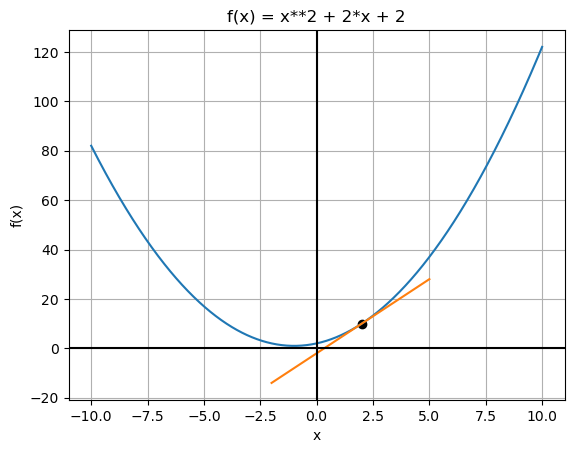

In [15]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=1)

x = np.linspace(-10, 10, 1000) # x values for the function
y = x**2 + 2*x + 2             # corresponding y values of the function
ax.plot(x,y)                   # plot the function

ax.scatter(2, 10, c = 'black') # draw point P

m=6
c=-2
x1 = np.linspace(-2, 5, 100) # x values for the tangent line
y1 = m*x1 + c           # corresponding y values for the tangent line
ax.plot(x1,y1)


plt.xlabel('x')
plt.ylabel('f(x)')
plt.title("f(x) = x**2 + 2*x + 2")
plt.grid()
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
plt.show();

**Task 1:** Verify that the derivative of the following function at the point $(9,12)$ is $\large \frac{2}{3}$. Do it by differentiation rules, and then by first principle on paper pencil, verify using Python code, and finally draw plot of the function and its derivative.<br>
$$\large f(x) = 4\sqrt{x}$$


**Task 2:** Verify that the derivative of the following function at the point $(4,6)$ is $\large \frac{-3}{2}$. Do it by differentiation rules, and then by first principle on paper pencil, verify using Python code, and finally draw plot of the function and its derivative.<br>
$$\large f(x) = \frac{3x}{x-2}$$


## e. How to Find Minima & Maxima using Derivatives?
<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">Maxima and minima (Extrema) of a function are the largest and smallest value of the function respectively, either within a given range or on the entire domain. </font></center>

<img align="center" width="700"  src="images/minima-maxima1.png"  >

>- Second derivative of a function tells us the curvature of the function's graph. If the second-order derivative value is positive, then the graph of a function is upwardly concave, If the second-order derivative value is negative, then the graph of a function is downwardly concave. If the second-order derivative value is also zero, then we cannot conclude anything about the curvature.
    
- If $f'(x)=0$ and $f''(x) > 0$ at $x=a$, then the function $f(x)$ has a local minimum at $a$. For example  $f(x)=x^2$
- If $f'(x)=0$ and $f''(x) < 0$ at $x=a$, then the function $f(x)$ has a local maximum at $a$. For example  $f(x)=-x^2$
- If $f'(x)=0$ and $f''(x) = 0$ at $x=a$, then we cannot conclude. For example $f(x)=x^4$ or $f(x)=-x^4$. For this we have to analyze the first derivative.
>- **Local minima:** If $f’(x)$ changes sign from negative to positive, as $x$ increases via point $a$, then $f(a)$ gives the minimum value of the function in that range.
>- **Local maxima:** If $f’(x)$ changes sign from positive to negative, as $x$ increases via point $a$, then $f(a)$ gives the maximum value of the function in that range.

### Example Function:
<img align="right" width="700"  src="images/minimas-maximas.png"  >

<font face = "Courier New" color=blue size=5>$\large f(x) = -x^4 + 3x^2$</font><br><br>
<font face = "Courier New" color=green size=5>$\large f'(x) = -4x^3 + 6x$</font><br><br>

$\large -4x^3 + 6x = 0$<br><br>
$\large x = -\sqrt{\frac{3}{2}}, 0, \sqrt{\frac{3}{2}} $

### Animation:
<img src="https://upload.wikimedia.org/wikipedia/commons/2/2d/Tangent_function_animation.gif"   style="width: 500px;"/>

## f. Partial Derivatives (Gradient) of a Function
<h3 align="center"><div class="alert alert-success" style="margin: 20px">Gradient of a function at any point is just a collection of all its partial derivatives with respect to all the dimensions of that function.</h3>
    
- In case of function of two or more variables we take partial derivatives.
- To find the partial derivative of a function with respect to one variable, all the other variables are treated as constant.<br><br>

- **Example 1:** <font face = "Courier New" color=red size=3>$\hspace{4cm}\large f(x,y) = x^2 - 3xy$</font><br>
$\hspace{4cm}\large \frac{\partial{f}}{\partial{x}} = \small 2x - 3y \hspace{3cm}\large \frac{\partial{f}}{\partial{y}} = \small -3x$<br><br>

- **Example 2:** <font face = "Courier New" color=red size=3>$\hspace{4cm}\large f(x,y) = 2x^2 + 4xy$</font><br>
$\hspace{4cm}\large \frac{\partial{f}}{\partial{x}} = \small 4x + 4y \hspace{3cm}\large \frac{\partial{f}}{\partial{y}} = \small 4x$<br><br>

- **Example 3:** <font face = "Courier New" color=red size=3>$\hspace{4cm}\large f(x,y,z) = z^3 - x^2y$</font><br>
$\hspace{4cm}\large \frac{\partial{f}}{\partial{x}} = \small -2xy \hspace{3cm}\large \frac{\partial{f}}{\partial{y}} = \small -x^2 \hspace{3cm}\large \frac{\partial{f}}{\partial{z}} = \small 3z^2$<br><br>

- **Example 4:** <font face = "Courier New" color=red size=3>$\hspace{4cm}\large f(x,y,z) = x^4 - 3xyz$</font><br>
$\hspace{4cm}\large \frac{\partial{f}}{\partial{x}} = \small 4x^3-3yz \hspace{3cm}\large \frac{\partial{f}}{\partial{y}} = \small -3xz \hspace{3cm}\large \frac{\partial{f}}{\partial{z}} = \small -3xy$<br><br><br>

    
    
<font face = "Courier New" color=green size=4>$$ \text{Gradient}  = \nabla = [\frac{\partial{f}}{\partial{x}}, \frac{\partial{f}}{\partial{y}}, \frac{\partial{f}}{\partial{z}}, \cdots]$$

### (i) 3-D Scatter Plot
**Example:** Draw a scatter plot of some random values of the following function:
$$\large f(x,y) = x^2 - 3xy$$

In [16]:
import numpy as np
from matplotlib import pyplot as plt

# define your function (it is passed two values (x and y) and it returns f(x,y))
def func(x,y):
    return  x**2 - 3*x*y

x = np.array([2, 1, 1, 3, 1, 3, 3, 2, 2, 4])
y = np.array([2, 3, 2, 3, 4, 1, 2, 3, 4, 2])
fxy = func(x,y)
print("x: ", x)
print("y: ", y)
print("f(x,y): ", fxy)

x:  [2 1 1 3 1 3 3 2 2 4]
y:  [2 3 2 3 4 1 2 3 4 2]
f(x,y):  [ -8  -8  -5 -18 -11   0  -9 -14 -20  -8]


<IPython.core.display.Javascript object>


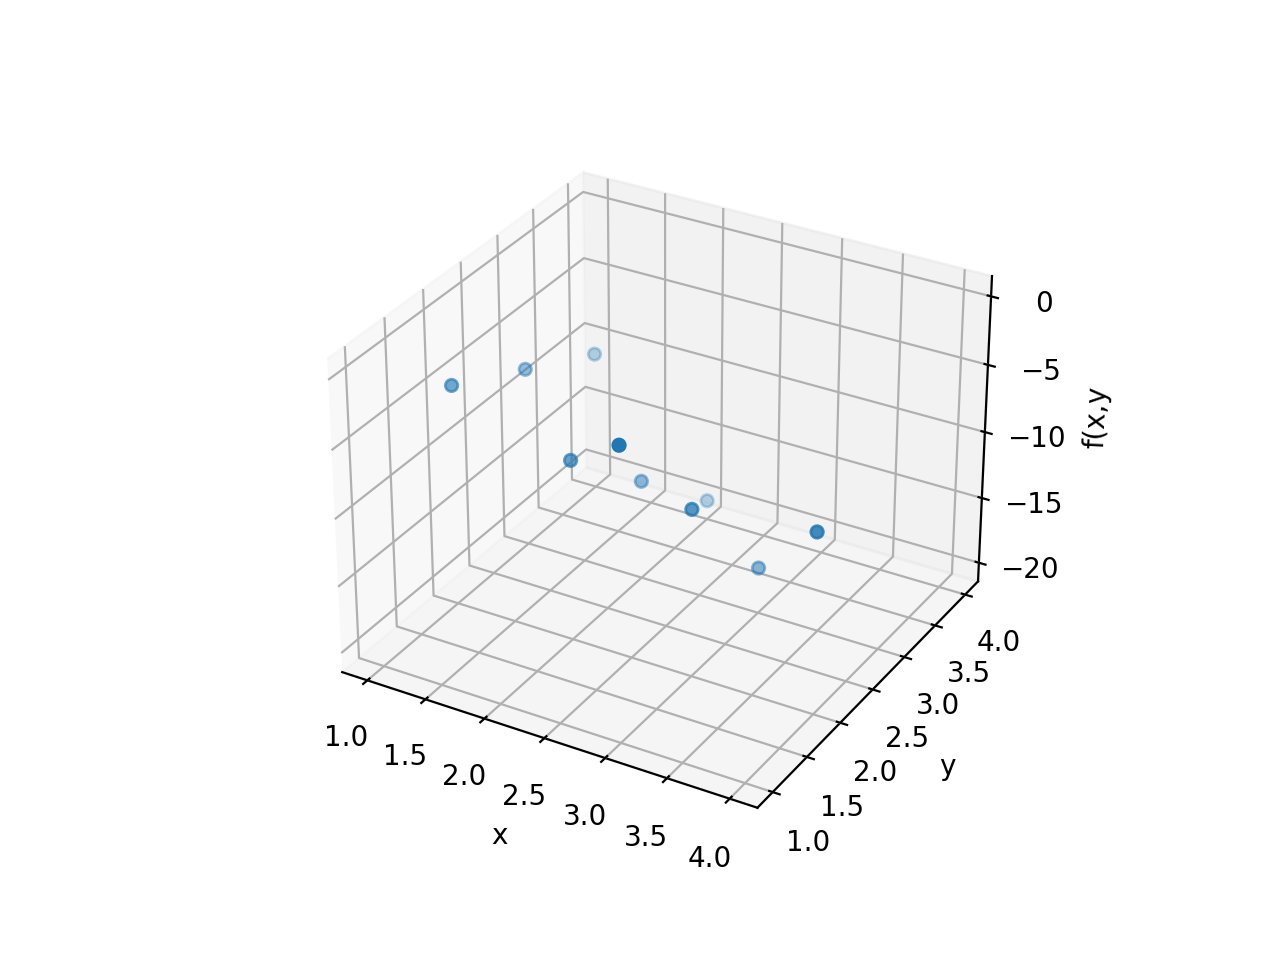

In [17]:
%matplotlib notebook
ax = plt.axes(projection='3d')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y')

ax.scatter3D(x,y,fxy);

### (ii) 3-D Surface Plot
**Example:** Draw a surface plot of some random values of the following function:
$$\large f(x,y) = x^2 - 3xy$$

In [19]:
import numpy as np
from matplotlib import pyplot as plt

def func_xy(x,y):
    return  x**2 - 3*x*y

x = np.linspace(-5,5,20)
y = np.linspace(-5,5,20)
fxy = func_xy(x,y)
print("x.shape: ", x.shape)
print("y.shape: ", y.shape)
print("f(x,y).shape: ", fxy.shape)

x.shape:  (20,)
y.shape:  (20,)
f(x,y).shape:  (20,)


In [20]:
X,Y = np.meshgrid(x,y)
fxy = func_xy(X,Y)

print("X.shape: ", X.shape)
print("Y.shape: ", Y.shape)
print("f(x,y).shape: ", fxy.shape)

X.shape:  (20, 20)
Y.shape:  (20, 20)
f(x,y).shape:  (20, 20)


<IPython.core.display.Javascript object>


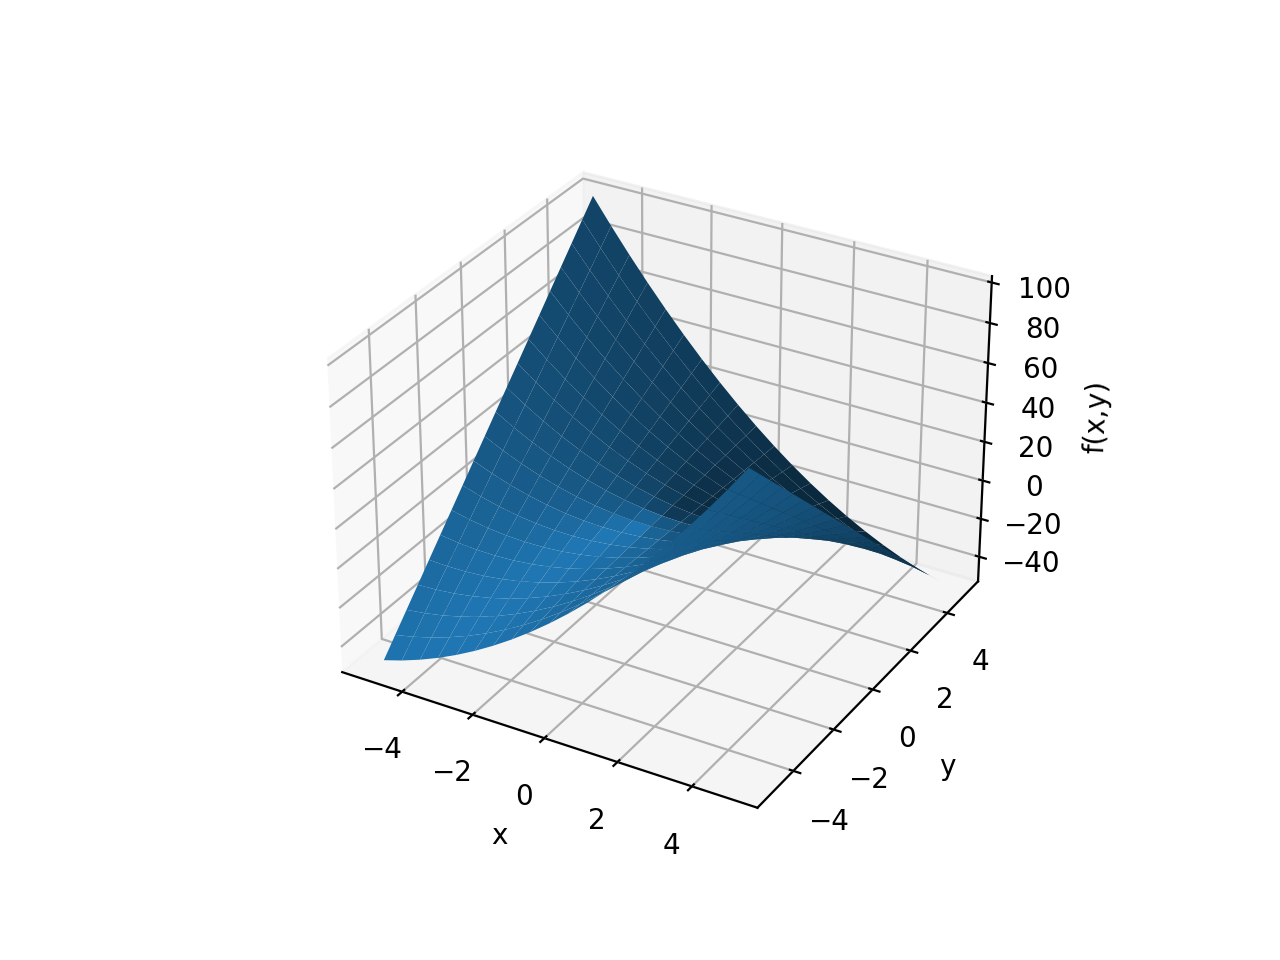

In [21]:
%matplotlib notebook
ax = plt.axes(projection='3d')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')

ax.plot_surface(X,Y,fxy);

### (iii) Calculate the gradiant of a Function with Two Variables
**Example 1:** Find the gradiant of the following function at the point $(4, 2, -8)$
$$\large f(x,y) = x^2 - 3xy$$

**Using Differentiation Rules:**

$\large \frac{\partial{f}}{\partial{x}} = 2x - 3y$<br><br>
$\large \frac{\partial{f}}{\partial{y}} = -3x$<br>


<font face = "Courier New" color=black size=4>$ \text{Gradient at x=4 and y=2:}  = \nabla = [2, -12]$

**Using First Principle:**
<font face = "Courier New" color=red size=3>$$\large \frac{dy}{dx} = f'(x_0) =\lim_{Δ \to 0} \frac{f(x_0 + Δ) - f(x_0)}{Δ} $$</font>

In [1]:
# define your function (it is passed two values (x and y) and it returns f(x,y))
def f(x, y):
    return x**2 - 3*x*y

In [2]:
# grad() function returns a vector containing partial derivatives of function f along all the dimensions
# idx is the index of *args list, specifying the variable with respect to which we want to differentiate function f
def grad(f, idx, *args):
    delta = 0.00001
    fxy = f(*args)        #value of function at the values x and y
    
    args = list(args)
    args[idx] += delta
    fxy1 = f(*args)      #value of function at the values x+Δ and y OR x and y+Δ
    
    return (fxy1-fxy)/delta     # First Principle

In [3]:
#calculate the partial derivative w.r.t x, at x=4,y=2
grad(f, 0, 4, 2)

2.0000099997474763

In [4]:
#calculate the partial derivative w.r.t y, at x=4,y=2
grad(f, 1, 4, 2)

-12.000000000256248

# 2. Gradient Descent Algorithm
<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">Gradient Descent algorithm is the most important and most fundamental algorithm in all of DL and is also used in ML & AI</font></center>

## a. Mountain Analogy for Gradient Descent Algorithm
<img align="center" width="1000"  src="images/mountains.png"  >

### 100$ Questions
1. `From where to start?`
2. `Which direction to move?`
3. `Size of step to take? `
4. `When to stop?`

## b. What is Gradient Descent and How to do Gradient Descent?
<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">Gradient Descent is a first-order iterative optimization algorithm for finding a local minimum of a differentiable function. The idea is to take repeated steps in the opposite direction of the gradient of the function at the current point.</font></center>    

<img align="center" width="1000"  src="images/GD-33.png"  >

## c. Gradient Descent (1-D) in Python

**Example Function:**
<font face = "Courier New" color=green size=3>$\hspace{2cm}\large f(x) = 3x^2 - 3x + 4 \hspace{3cm}$</font>
<font face = "Courier New" color=green size=3>$\large f'(x) = 6x - 3$</font><br><br>

$\large 6x - 3=0 \implies x = \frac{1}{2}$

In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# function (as a function)
def fx(x):
  return 3*x**2 - 3*x + 4

# derivative function
def deriv(x):
  return 6*x - 3

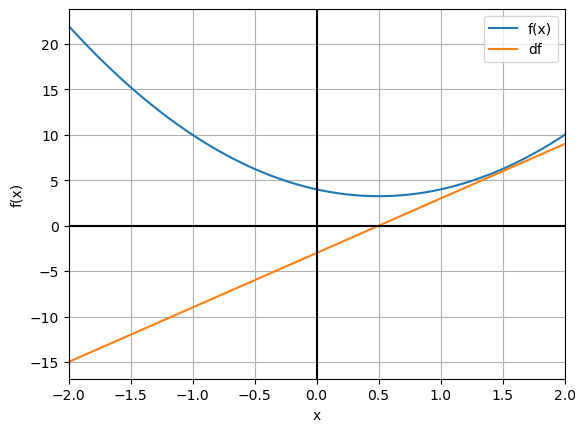

In [28]:
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=1)
x = np.linspace(-2,2,2000)
plt.plot(x, fx(x))
plt.plot(x, deriv(x))
plt.xlim(x[[0,-1]])
plt.grid()
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(["f(x)","df"])
plt.show()

In [29]:
guess_min = 2          # See impact of changing this parameter of GD
print("Initial Guess: ", guess_min)
# learning parameters
alpha = 0.1     # See impact of changing this parameter of GD
epochs = 10  # See impact of changing this parameter of GD

# run through training
for i in range(epochs):
    guess_min = guess_min - alpha * deriv(guess_min)

localmin = guess_min
print("Local Minimum: ", localmin)

Initial Guess:  2
Local Minimum:  0.5001572864


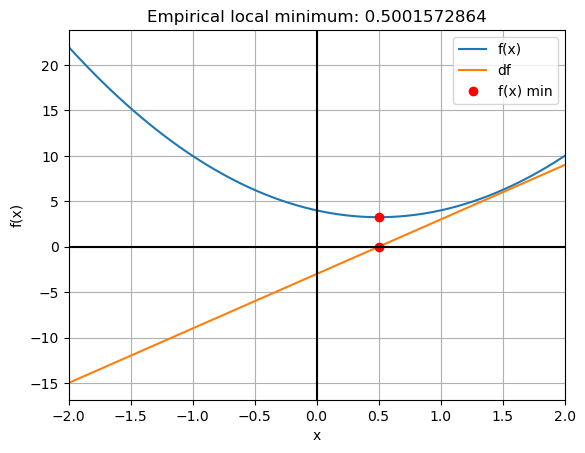

In [30]:
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.plot(x,fx(x), x,deriv(x))
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Empirical local minimum: %s'%localmin)
plt.show()

## d. Challenges of Gradient Descent Algorithm
- Gradient Descent algorithm is not guaranteed to give us the correct solution. There are several circumstances that can make Gradient Descent algorithm either go completely wrong or just a bit wrong:
    - Poor choice of model parameters
    - Stuck in a local minimum due to unfortunate starting point
    - Vanishing Gradient
    - Exploding Gradient

## (i) Small vs Large Learning Rate


<img align="center" width="1000"  src="images/bad-learning-rate-values.png"  >


## (ii) Local Minima and Unfortunate Starting Point

<font face = "Courier New" color=blue size=4>$\hspace{6cm}\large f(x) = cos(2\pi x) + x^2 \hspace{3cm}$</font>
<font face = "Courier New" color=orange size=4>$\large f'(x) = -2\pi sin(2\pi x) +2x$</font><br><br>

<img align="center" width="700"  src="images/local-global-minima1.png"  >


- There are various methods that help in overcoming the local minimum and unfortunate starting point:
    - Use stochastic Gradient Descent

## (iii) Vanishing Gradient Problem
<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">Vanishing gradient descent is a problem that occurs when the gradient become exponentially small and when multiplied with learning rate the step size becomes so much small that you donot reach the function minimum in specified epochs.</font></center>    
<img align="center" width="600"  src="images/vanishing-gradient.png"  >
    
- In Deep Learning, there are various techniques that help in overcoming the vanishing gradient problems:
    - Instead of sigmoid activation function use activation functions that do not saturate like Rectified Linear Unit (ReLU, Leaky-ReLU, Randomized ReLU)
    - Long Short Term Memory (LSTM)
    - Gated Recurrent Unit (GRU)

## (iv) Exploding Gradient Problem
<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">Exploding gradient is a problem that occurs when the gradient is too steep/large and when multiplied with learning rate the step size becomes so much large that you may miss the minimum and cross the other side.</font></center>    
<img align="center" width="600"  src="images/exploding-gradient.png"  >
    
- There are various methods that help in overcoming the exploding gradient problem:
    - Gradient Clipping
    - Layer-wise Adaptive Rate Scaling
    - Long Short Term Memory (LSTM)

# 3. Linear Regression Using Gradient Descent Algorithm

## a. Recap of Linear Regression using OLS
- **Cost Function:**
<font face = "Courier New" color=green size=5>$$\large E(\beta_0, \beta_1, \beta_2, \cdots, \beta_m) = \sum_{i=1}^n (y_i - \hat{y_i})^2 = \sum_{i=1}^n (y_i - (\beta_0 + \sum_{i=1}^m \beta_i x_i))^2$$</font><br>


- **Regression Coefficients for Simple Linear Regression:**

<font face = "Courier New" color=magenta size=5>$\hspace{3cm}\large\beta_1 =$</font> <font face = "Courier New" color=magenta size=6>$\large\frac{    \bar{(x_iy_i)} - \bar{x_i} {\bar{y_i}}}      {\bar{x_i^2} - \bar{x_i}^2}$</font>
<font face = "Courier New" color=magenta size=5>$\hspace{3cm}\large \beta_0 = \bar{y_i} - \beta_1\bar{x_i}$</font>


- **Regression Coefficients for Multiple Linear Regression:**

<font face = "Courier New" color=red size=5>$$\large \hspace{2cm}    \beta = (X^TX)^{-1}X^TY$$</font><br><br>
    
- **Limitation of using Ordinary Least Squares:**
>- Taking the derivative of cost function and then solving it for zero to get the set of $\beta$ coefficients becomes computationally expensive when the number of input features are in thousands or even millions.
>- The Gauss Jordan Elimination technique of computing the inverse of a nxn matrix is $O(n^3)$. So for 999 input features the size of X matrix will be $1000\times1000$, and the complexity of computing the inverse of this matrix will be $10^9$
>- Solution to this problem is `Gradient Descent` in which instead of using a closed form solution, we go slowly towards the answer using approximation technique

# 4. Example (Simple Linear Regression using Gradient Descent)
- Consider that a teacher has collected a sample data of seven students, their GPA and the number of hours they have studied on daily basis in the entire semester.
- Suppose, a teacher want to determine the relationship between the two variables `GPA` and `study hours` is positive or negative.
- The teacher also wants to determine how much impact the dependent variable `study hours` has on the independent variable `GPA`
- For this she has collected a sample data of seven students as tupple containing (`daily study hours` and `acquired GPA`):
 $$(1,\hspace{.2 cm}1.4), \hspace{.5 cm}(2,\hspace{.2 cm}1.6),\hspace{.5 cm}(3,\hspace{.2 cm}2.5),\hspace{.5 cm}(4,\hspace{.2 cm}2.6), \hspace{.5 cm}(5,\hspace{.2 cm}3.5),\hspace{.5 cm}(6,\hspace{.2 cm}3.7),\hspace{.5 cm}(7,\hspace{.2 cm}4.0) $$

In [32]:
import pandas as pd
df = pd.read_csv("datasets/study-hours.csv")
df

,study_hours,gpa
0,1.0,1.4
1,2.0,1.6
2,3.0,2.5
3,4.0,2.6
4,5.0,3.5
5,6.0,3.7
6,7.0,4.0


<img align="center" width="1200"  src="images/GD-LR11.png"  >

### (i) Minimizing Error Function for Gradient Descent Algorithm
<img align="center" width="1000"  src="images/GD-LR3.png"  >

$\large \frac{\partial{E}}{\partial{\beta_0}} = -\frac{1}{n}\sum(y_i - \hat{y}_i)$<br><br>
$\large \frac{\partial{E}}{\partial{\beta_1}} = -\frac{1}{n}\sum x_{i1}(y_i - \hat{y}_i)$<br><br>
$\large \frac{\partial{E}}{\partial{\beta_2}} = -\frac{1}{n}\sum x_{i2}(y_i - \hat{y}_i)$<br><br>
$\large \frac{\partial{E}}{\partial{\beta_3}} = -\frac{1}{n}\sum x_{i3}(y_i - \hat{y}_i)$<br><br>

### (ii) Calculate  Regression Coefficients Using GD

In [33]:
x = df['study_hours'].values
y = df['gpa'].values
n = df.shape[0]         # number of training examples

# Step 1: Start with some random values of y-intercept and coefficient(s) (Model Parameters)
beta0 = 0.0     
beta1 = 1.0

# Step 2: Set appropriate values for Learning Rate and Training Epochs (Hyperparameters)
alpha = 0.01    # learning rate  
epochs = 10000   # number of iteration/epochs

# Step 3: Update beta0 and beta1 in epoch iterations (Training)
for i in range(epochs):
    yhat = beta0 + beta1*x       #calculate yhat for entire dataset(predictions)
    
    # Calculate the gradients of the cost function 
    d_beta0 = (-1/n) * sum((y - yhat))         # wrt beta0
    d_beta1 = (-1/n) * sum(x * (y - yhat))    # wrt beta1
    
    # update the gradients
    beta0 = beta0 - alpha * d_beta0   # Update beta0
    beta1 = beta1 - alpha * d_beta1   # Update beta1
    
    
print("beta0 = {:.5f}\nbeta1 = {:.5f}\n".format(beta0, beta1))

beta0 = 0.90000
beta1 = 0.46429



### (iii) Fit the Line

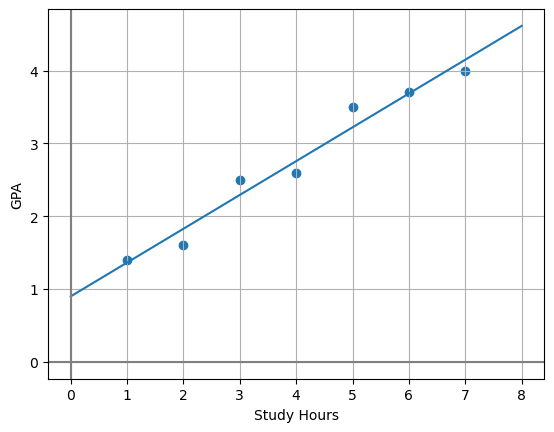

In [34]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

x = np.array(df['study_hours'])
y = np.array(df['gpa'])

fig, ax = plt.subplots(nrows=1, ncols=1)
plt.scatter(x,y)

xpointsofline = np.linspace(0, 8, 1000)
ypointsofline = beta0 + beta1 * xpointsofline
plt.plot(xpointsofline, ypointsofline)

plt.grid()
plt.axvline(x=0, color='gray')
plt.axhline(y=0, color='gray')
plt.xlabel('Study Hours')
plt.ylabel('GPA')
plt.show()

### (iv) Carry out the Prediction:
<font face = "Arial" color=red size=3>A student has studied for 4.6 hours per day in the entire semester. Can you predict his/her GPA? </font>
<center><font face = "Courier New" color=red size=4>$ \large \hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i $</font>

In [35]:
sh = 4.6
gpa = beta0 + beta1 * sh
print("If a student studies 4.6 hours daily, his/her predicted GPA is: {:.3f}".format(gpa))

If a student studies 4.6 hours daily, his/her predicted GPA is: 3.036


### (v) A Deep Dive: Calculate  Regression Coefficients Using GD

###  Calculate Partial Derivatives of Error Function
$$(1,\hspace{.2 cm}1.4), \hspace{.5 cm}(2,\hspace{.2 cm}1.6),\hspace{.5 cm}(3,\hspace{.2 cm}2.5),\hspace{.5 cm}(4,\hspace{.2 cm}2.6), \hspace{.5 cm}(5,\hspace{.2 cm}3.5),\hspace{.5 cm}(6,\hspace{.2 cm}3.7),\hspace{.5 cm}(7,\hspace{.2 cm}4.0) $$

#### Derivative of Error Function w.r.t $\beta_0$:
$$\large \frac{\partial{E}}{\partial{\beta_0}} = -\frac{1}{n}\sum(y_i - \beta_0 - \beta_1 x_i)$$<br>

$\hspace{1cm}\large \frac{\partial{E}}{\partial{\beta_0}} = -\frac{1}{7}[\small(1.4 - \beta_0 - \beta_1)+(1.6 - \beta_0 - 2\beta_1)+(2.5 - \beta_0 - 3\beta_1)+(2.6 - \beta_0 - 4\beta_1)+(3.5 - \beta_0 - 5\beta_1)+(3.7 - \beta_0 - 6\beta_1)+(4 - \beta_0 - 7\beta_1) \large]$<br><br>
<font face = "Courier New" color=red size=4>$\hspace{1cm}\large \frac{\partial{E}}{\partial{\beta_0}} \small = \beta_0 + 4\beta_1 - 2.758 \hspace{1cm}.... (i)$</font><br><br>

#### Derivative of Error Function w.r.t $\beta_1$:
$$\large \frac{\partial{E}}{\partial{\beta_1}} = -\frac{1}{n}\sum x_i(y_i - \beta_0 - \beta_1 x_i)$$<br>
$\hspace{1cm}\large \frac{\partial{E}}{\partial{\beta_1}} = -\frac{1}{7}[\small(1.4 - \beta_0 - \beta_1)+2*(1.6 - \beta_0 - 2\beta_1)+3*(2.5 - \beta_0 - 3\beta_1)+4*(2.6 - \beta_0 - 4\beta_1)+5*(3.5 - \beta_0 - 5\beta_1)+6*(3.7 - \beta_0 - 6\beta_1)+7*(4 - \beta_0 - 7\beta_1) \large]$<br><br>
<font face = "Courier New" color=red size=4>$\hspace{1cm}\large \frac{\partial{E}}{\partial{\beta_1}} \small = \beta_0 + 5\beta_1 - 3.223  \hspace{1cm}.... (ii)$</font><br><br>


#### Python Functions to Calculate Partial Derivative at specific values:

In [ ]:
def deriv_beta0(beta0,beta1):
  return beta0 + 4*beta1 - 2.758

def deriv_beta1(beta0,beta1):
  return beta0 + 5*beta1 - 3.223

>- Here to keep things simple, I have hard coded every thing. 
>- Please write your own function that is passed the error function name, the index of the argument/variable w.r.t which you want to differentiate and the values of $\beta_0$ and $\beta_1$ at which you want to calculate the slope. (This we have done above) 

#### Another Implementation of GD Algorithm:

In [ ]:
# Step 1: Start with some random values of y-intercept and coefficient(s) (Model Parameters)
beta0 = 0.0     
beta1 = 1.0

# Step 2: Set appropriate values for Learning Rate and Training Epochs (Hyperparameters)
alpha = 0.1    # learning rate  
epochs = 500   # number of iteration/epochs

# Step 3: Update beta0 and beta1 in epoch iterations (Training)
print('Guess:   beta0_grad {:.3}, beta1_grad {:.3}'.format(beta0, beta1))
for i in range(epochs):
    beta0 = beta0 - alpha * deriv_beta0(beta0, beta1)
    beta1 = beta1 - alpha * deriv_beta1(beta0, beta1)
    
    print('Epoch {}, beta0_grad {:.3}, beta1_grad {:.3}'.format(i, beta0, beta1))


$\large \beta_0 = 0.89 \hspace{2cm}\beta_1 = 0.46$

# 5. Example (Multiple Linear Regression using Gradient Descent)
**Dataset Description**

- `number_courses`: Number of Courses Opted by the student
- `time_study`: Average Time Studied per day by the student
- `Marks`: Marks Obtained by the student

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('datasets/Student_Marks.csv')
df

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


# a. Batch Gradient Descent
- Batch gradient descent (SGD) calculates the gradient using a the entire dataset in each iteration, therefore, requires the entire training dataset to be in memory and available to the algorithm.


\begin{equation}
\large \beta_{t+1} = \beta_t - \alpha \nabla f(\beta_t)
\end{equation}

where 
- $\beta_t$ is the weight vector at time $t$
- $\alpha$ is the learning rate
- $\nabla f(\beta_t)$ is the gradient of the loss function $f$ with respect to $\beta_t$.


In [37]:
x1 = df.number_courses.values  # first input feature
x2 = df.time_study.values      # second input feature
y = df.Marks.values            # output feature

# Step 1: Start with some random values of y-intercept and coefficients (Model Parameters)
beta0 , beta1, beta2 = 0,0,0      # weights initilization 

# Step 2: Set appropriate values for Learning Rate and Training Epochs (Hyperparameters)
alpha = 0.01           # learning rate 
epochs = 10000          # number of iteration/epochs
n = df.shape[0]         # number of training examples

# Step 3: Update betas using Batch/Vanilla Gradient Descent Algorithm (Training)

for i in range(epochs):
    yhat = beta0 + beta1*x1 + beta2*x2       #calculate yhat (predictions)
    
    # Calculate the gradients of the cost function 
    d_beta0 = (-1/n) * sum((y - yhat))         # wrt beta0
    d_beta1 = (-1/n) * sum(x1 * (y - yhat))    # wrt beta1
    d_beta2 = (-1/n) * sum(x2 * (y - yhat))    # wrt beta2
    
    # update the gradients
    beta0 = beta0 - alpha * d_beta0   # Update beta0
    beta1 = beta1 - alpha * d_beta1   # Update beta1
    beta2 = beta2 - alpha * d_beta2   # Update beta2
    
    
print("beta0 = {:.5f}\nbeta1 = {:.5f}\nbeta2 = {:.5f} \n".format(beta0, beta1,beta2))

beta0 = -7.45526
beta1 = 1.86390
beta2 = 5.39913 



# b. Stochastic Gradient Descent
- Stochastic gradient descent (SGD) calculates the gradient using a single sample at a time.
- In contrast to Batch GD, Stochastic GD updates the model parameters in each epoch by considering one record at a time. The advantage is it may converge faster and is not memory hungry like Batch GD


\begin{equation}
\large \beta_{t+1} = \beta_t - \alpha \nabla f_i(\beta_t)
\end{equation}


where,
- $\beta_t$ is the weight vector at time $t$
- $\alpha$ is the learning rate
- $i$ is a randomly chosen index from the training set
- $\nabla f_i(\beta_t)$ is the gradient of the loss function $f$ with respect to $\beta_t$ for the training example indexed by $i$

In [38]:
x1 = df.number_courses.values  # first input feature
x2 = df.time_study.values      # second input feature
y = df.Marks.values            # output feature

# Step 1: Start with some random values of y-intercept and coefficients (Model Parameters)
beta0 , beta1, beta2 = 0,0,0      # weights initilization 

# Step 2: Set appropriate values for Learning Rate and Training Epochs (Hyperparamaeters)
alpha = 0.01           # learning rate 
epochs = 10000          # number of iteration/epochs

n = df.shape[0]         # number of training examples

# Step 3: Update betas using Stochastic Gradient Descent Algorithm (Training)
for i in range(epochs):
    # Select a random index from the training examples
    idx = np.random.randint(0, n)
    # Get the corresponding input values
    x1_i, x2_i, y_i = x1[idx], x2[idx], y[idx]
    # Get the prediction for the current input using the current weights 
    yhat_i = beta0 + beta1*x1_i + beta2*x2_i       #calculate yhat (predictions)
    
    # Calculate the gradients of the cost function 
    d_beta0 = (-1) * (y_i - yhat_i)         # wrt beta0
    d_beta1 = (-1) * x1_i * (y_i - yhat_i)    # wrt beta1
    d_beta2 = (-1) * x2_i * (y_i - yhat_i)    # wrt beta2
    
    # update the gradients
    beta0 = beta0 - alpha * d_beta0   # Update beta0
    beta1 = beta1 - alpha * d_beta1   # Update beta1
    beta2 = beta2 - alpha * d_beta2   # Update beta2

    
print("beta0 = {:.5f}\nbeta1 = {:.5f}\nbeta2 = {:.5f} \n".format(beta0, beta1,beta2))

beta0 = -8.11307
beta1 = 1.52788
beta2 = 5.15462 



# c. Mini-batch Gradient Descent
- Suppose you have 100 observations you make four batches of 25 observations each and in turn you get four betas. Finally you select the best betas for your model.
- Mini-batch gradient descent is a combination of the concepts of SGD and batch gradient descent. It simply splits the training dataset into small batches and performs an update for each of those batches. This creates a balance between the robustness of stochastic gradient descent and the efficiency of batch gradient descent.

\begin{equation}
\large \beta_{t+1} = \beta_t - \alpha \nabla f_{B_t}(\beta_t)
\end{equation}


where,
- $\beta_t$ is the weight vector at time $t$
- $\alpha$ is the learning rate
- $B_t$ is a randomly chosen mini-batch of examples from the training set
- $\nabla f_{B_t}(\beta_t)$ is the average gradient of the loss function $f$ with respect to $\beta_t$ for the examples in the mini-batch $B_t$

In [39]:
x1 = df.number_courses.values  # first input feature
x2 = df.time_study.values      # second input feature
y = df.Marks.values            # output feature

# Step 1: Start with some random values of y-intercept and coefficients
beta0 , beta1, beta2 = 0,0,0      # weights initilization 

# Step 2: Set appropriate values for Learning Rate and Training Epochs
alpha = 0.01      # learning rate 
epochs = 10000     # number of iteration/epochs
batch_size = 32    # set of batch size

n = df.shape[0]    # number of training examples

# Step 3: Update betas using Mini-Batch Gradient Descent Algorithm
for i in range(epochs):
    # create a batch
    random_indices = np.random.randint(n, size=batch_size)   # select random indices
    batch_x1 = x1[random_indices]
    batch_x2 = x2[random_indices]
    batch_y = y[random_indices]
   
    # Get the prediction for the current input using the current betas 
    batch_yhat = beta0 + beta1*batch_x1 + beta2*batch_x2       #calculate yhat (predictions)
    
    # Calculate the gradients of the cost function 
    d_beta0 = (-1/batch_size) * sum((batch_y - batch_yhat))              # wrt beta0
    d_beta1 = (-1/batch_size) * sum(batch_x1 * (batch_y - batch_yhat))   # wrt beta1
    d_beta2 = (-1/batch_size) * sum(batch_x2 * (batch_y - batch_yhat))   # wrt beta2
    
    # update the gradients
    beta0 = beta0 - alpha * d_beta0   # Update beta0
    beta1 = beta1 - alpha * d_beta1   # Update beta1
    beta2 = beta2 - alpha * d_beta2   # Update beta2

    
print("beta0 = {:.5f}\nbeta1 = {:.5f}\nbeta2 = {:.5f} \n".format(beta0, beta1,beta2))

beta0 = -7.52640
beta1 = 1.87194
beta2 = 5.45347 



# d. Using Scikit-Learn's `SGDRegressor`

In [31]:
from sklearn.linear_model import SGDRegressor
import pandas as pd

In [40]:
from sklearn.linear_model import SGDRegressor
import pandas as pd

df = pd.read_csv('datasets/Student_Marks.csv')
X = df.drop('Marks', axis=1)
y = df.Marks.values 

model = SGDRegressor(loss = 'squared_loss', penalty='l2', learning_rate = 'constant', eta0=0.01, max_iter= 100000)
model.fit(X,y)

print("beta0 = {:.5f}".format(model.intercept_[0]))
print("beta1 = {:.5f}".format(model.coef_[0]))
print("beta2 = {:.5f}".format(model.coef_[1]))

beta0 = -5.39756
beta1 = 1.34722
beta2 = 4.82942


# 5. Task To Do (Gradient Descent on 4D Dataset)
## Use Batch GD
## Use Stochastic GD
## Use Mini-Batch GD

### a. Use Anscombe's Quartet Dataset (Simple Linear Regression)

In [41]:
import seaborn as sns
import numpy as np
import pandas as pd
df_anscombe = sns.load_dataset('anscombe')
df_anscombe.sample(10)

,dataset,x,y
1,I,8.0,6.95
38,IV,8.0,7.04
21,II,5.0,4.74
11,II,10.0,9.14
27,III,14.0,8.84
32,III,5.0,5.73
20,II,7.0,7.26
9,I,7.0,4.82
10,I,5.0,5.68
6,I,6.0,7.24


### b. Use Advertising Dataset (Multiple Linear Regression)

In [42]:
import pandas as pd
df = pd.read_csv("datasets/advertising4D.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5
